# Peliculas Rotten-Tomatoes
 
En nuestro proyecto vamos a utilizar el rotten_tomatoes_movies.csv
 
Objetivos:
1. Cargar datos.
2. Limpieza y preparación de datos.
3. Análisis exploratorio.
 
    3.1 Estadísticas globales
 
    3.2 Análisis por género
 
    3.3 Análisis por estudio o director
 
    3.4 Análisis temporal
   
    3.5 Análisis de retraso a streaming (si aplica)
4. Uso de NumPy para análisis auxiliar.
5. Preguntas.
6. Conclusiones.

## 1. Carga de datos

In [ ]:
# Instala pandas en el kernel actual (usa %pip para asegurar instalación en este entorno)
%pip install -q pandas
%pip install -q numpy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Aquí vamos a utilizar nuestro csv que es el rotten_tomatoes_movies.csv
df = pd.read_csv("rotten_tomatoes_movies.csv")

# Mostramos las primeras filas de nuestro csv
display(df.head())

# Como nuestro csv mayoritariamente tiene texto utilizaremos el .info en vez del .describe que es para numéricas
df.info()

# Estadísticas básicas de todas las columnas
display(df.describe(include='all'))

#Conversion de tipos
print("Tipos ANTES:")
print(df.dtypes)

# Conversión in_theaters_date y on_streaming_date a datetime
df['in_theaters_date'] = pd.to_datetime(df['in_theaters_date'], errors='coerce', dayfirst=True)
df['on_streaming_date'] = pd.to_datetime(df['on_streaming_date'], errors='coerce', dayfirst=True)

# Conversion in_theaters_date y on_streaming_date a datetime
df['runtime_in_minutes'] = pd.to_numeric(df['runtime_in_minutes'], errors='coerce')
df['tomatometer_rating'] = pd.to_numeric(df['tomatometer_rating'], errors='coerce')
df['audience_rating'] = pd.to_numeric(df['audience_rating'], errors='coerce')
df['tomatometer_count'] = pd.to_numeric(df['tomatometer_count'], errors='coerce')
df['audience_count'] = pd.to_numeric(df['audience_count'], errors='coerce')



print("\nTipos DESPUÉS:")
print(df.dtypes)




Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


,movie_title,movie_info,critics_consensus,rating,genre,directors,writers,cast,in_theaters_date,on_streaming_date,runtime_in_minutes,studio_name,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count,columna_vacia
0,Percy Jackson & the Olympians: The Lightning T...,A teenager discovers he's the descendant of a ...,Though it may seem like just another Harry Pot...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,Craig Titley,"Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,2010-06-29,83.0,20th Century Fox,Rotten,49,144,53.0,254287.0,NaN
1,Percy Jackson & the Olympians: The Lightning T...,A teenager discovers he's the descendant of a ...,Though it may seem like just another Harry Pot...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,Craig Titley,"Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,2010-06-29,83.0,20th Century Fox,Rotten,49,144,53.0,254287.0,NaN
2,Please Give,Kate has a lot on her mind. There's the ethics...,Nicole Holofcener's newest might seem slight i...,R,Comedy,Nicole Holofcener,Nicole Holofcener,"Catherine Keener, Amanda Peet, Oliver Platt, R...",2010-04-30,2010-10-19,90.0,Sony Pictures Classics,Certified Fresh,86,140,64.0,11567.0,NaN
3,10,Blake Edwards' 10 stars Dudley Moore as George...,NaN,R,"Comedy, Romance",Blake Edwards,Blake Edwards,"Dudley Moore, Bo Derek, Julie Andrews, Robert ...",1979-10-05,1997-08-27,118.0,Waner Bros.,Fresh,68,22,53.0,14670.0,NaN
4,12 Angry Men (Twelve Angry Men),"A Puerto Rican youth is on trial for murder, a...",Sidney Lumet's feature debut is a superbly wri...,NR,"Classics, Drama",Sidney Lumet,Reginald Rose,"Martin Balsam, John Fiedler, Lee J. Cobb, E.G....",1957-04-13,2001-03-06,95.0,Criterion Collection,Certified Fresh,100,51,97.0,105000.0,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16639 entries, 0 to 16638
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   movie_title         16639 non-null  object 
 1   movie_info          16615 non-null  object 
 2   critics_consensus   8310 non-null   object 
 3   rating              16639 non-null  object 
 4   genre               16622 non-null  object 
 5   directors           16525 non-null  object 
 6   writers             15290 non-null  object 
 7   cast                16355 non-null  object 
 8   in_theaters_date    15824 non-null  object 
 9   on_streaming_date   16637 non-null  object 
 10  runtime_in_minutes  16484 non-null  float64
 11  studio_name         16223 non-null  object 
 12  tomatometer_status  16639 non-null  object 
 13  tomatometer_rating  16639 non-null  int64  
 14  tomatometer_count   16639 non-null  int64  
 15  audience_rating     16387 non-null  float64
 16  audi

,movie_title,movie_info,critics_consensus,rating,genre,directors,writers,cast,in_theaters_date,on_streaming_date,runtime_in_minutes,studio_name,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count,columna_vacia
count,16639,16615,8310,16639,16622,16525,15290,16355,15824,16637,16484.000000,16223,16639,16639.000000,16639.000000,16387.000000,1.638700e+04,0.0
unique,16106,16613,8307,8,1080,8314,12121,16326,5586,2260,NaN,2886,3,NaN,NaN,NaN,NaN,NaN
top,Hamlet,A teenager discovers he's the descendant of a ...,"Extinction has a few intriguing ideas, but the...",R,Drama,Alfred Hitchcock,Woody Allen,Werner Herzog,2002-01-01,2004-06-01,NaN,Paramount Pictures,Rotten,NaN,NaN,NaN,NaN,NaN
freq,5,2,2,6136,1727,36,33,4,28,71,NaN,497,7234,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.390318,NaN,NaN,60.465833,56.612357,60.470373,1.524859e+05,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.027707,NaN,NaN,28.586509,66.385262,20.461826,1.817681e+06,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,0.000000,5.000000,0.000000,5.000000e+00,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.000000,NaN,NaN,38.000000,12.000000,45.000000,8.645000e+02,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.000000,NaN,NaN,66.000000,28.000000,62.000000,4.877000e+03,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,111.000000,NaN,NaN,86.000000,76.000000,77.000000,2.876650e+04,NaN


Tipos ANTES:
movie_title            object
movie_info             object
critics_consensus      object
rating                 object
genre                  object
directors              object
writers                object
cast                   object
in_theaters_date       object
on_streaming_date      object
runtime_in_minutes    float64
studio_name            object
tomatometer_status     object
tomatometer_rating      int64
tomatometer_count       int64
audience_rating       float64
audience_count        float64
columna_vacia         float64
dtype: object

Tipos DESPUÉS:
movie_title                   object
movie_info                    object
critics_consensus             object
rating                        object
genre                         object
directors                     object
writers                       object
cast                          object
in_theaters_date      datetime64[ns]
on_streaming_date     datetime64[ns]
runtime_in_minutes           float64
studio_nam

C:\Users\Mark\AppData\Local\Temp\ipykernel_12520\1757371955.py:27: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['on_streaming_date'] = pd.to_datetime(df['on_streaming_date'], errors='coerce', dayfirst=True)


,movie_title,movie_info,critics_consensus,rating,genre,directors,writers,cast,in_theaters_date,on_streaming_date,runtime_in_minutes,studio_name,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count,columna_vacia
0,Percy Jackson & the Olympians: The Lightning T...,A teenager discovers he's the descendant of a ...,Though it may seem like just another Harry Pot...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,Craig Titley,"Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-12-02,2010-06-29,83.0,20th Century Fox,Rotten,49,144,53.0,254287.0,NaN
1,Percy Jackson & the Olympians: The Lightning T...,A teenager discovers he's the descendant of a ...,Though it may seem like just another Harry Pot...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,Craig Titley,"Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-12-02,2010-06-29,83.0,20th Century Fox,Rotten,49,144,53.0,254287.0,NaN
2,Please Give,Kate has a lot on her mind. There's the ethics...,Nicole Holofcener's newest might seem slight i...,R,Comedy,Nicole Holofcener,Nicole Holofcener,"Catherine Keener, Amanda Peet, Oliver Platt, R...",NaT,2010-10-19,90.0,Sony Pictures Classics,Certified Fresh,86,140,64.0,11567.0,NaN
3,10,Blake Edwards' 10 stars Dudley Moore as George...,NaN,R,"Comedy, Romance",Blake Edwards,Blake Edwards,"Dudley Moore, Bo Derek, Julie Andrews, Robert ...",1979-05-10,1997-08-27,118.0,Waner Bros.,Fresh,68,22,53.0,14670.0,NaN
4,12 Angry Men (Twelve Angry Men),"A Puerto Rican youth is on trial for murder, a...",Sidney Lumet's feature debut is a superbly wri...,NR,"Classics, Drama",Sidney Lumet,Reginald Rose,"Martin Balsam, John Fiedler, Lee J. Cobb, E.G....",NaT,2001-03-06,95.0,Criterion Collection,Certified Fresh,100,51,97.0,105000.0,NaN


## 2. Limpieza y preparación de datos

In [10]:
# Detectar filas duplicadas completas
duplicados = df[df.duplicated()]
print("Filas duplicadas detectadas:")
display(duplicados)

# Eliminar duplicados
df.drop_duplicates(inplace=True)

print("Tamaño tras eliminar duplicados:", df.shape)

# Conteo de valores nulos por columna
print("Valores nulos por columna:")
print(df.isna().sum())

# Eliminamos columnas que estén completamente vacías
print("Columnas actuales del DataFrame:")
print(df.columns.tolist())
df.dropna(axis=1, how='all', inplace=True)

print("Columnas actuales del DataFrame:")
print(df.columns.tolist())

# Normalizar el campo genre:
# - quitar espacios en blanco
# - poner la primera letra en mayúscula de cada palabra
# - eliminar espacios internos (Acción  -> Acción, 'Ciencia Ficcion' -> 'CienciaFiccion')
df['genre'] = (
    df['genre']
      .astype(str)
      .str.strip()
      .str.title()
      .str.replace(' ', '', regex=False)
)
 
display(df[['genre']].head(10))
 
# Buscar todas las filas que contienen "Horror"
horror_rows = df[df['genre'].str.contains('Horror', case=False, na=False)]
print("Filas con Horror:")
display(horror_rows)

# Aquí vamos a hacer distintas columnas derivadas que nos serviran para hacer distintas busquedas

    # Empezaremos mostrando la diferencia de días entre el estreno en cines y el estreno en teatros.
df['days_to_streaming'] = df['on_streaming_date'] - df['in_theaters_date'] 
print("[Días de diferencia en el estreno")
display(df[['movie_title', 'days_to_streaming']])

#Ahora vamos a contar el total de votos, sumando los votos del tomatometer y los de la audiencia 
df['total_votes'] = df['tomatometer_count'] + df['audience_count']

print("Cantidad de votos")
display(df[['movie_title', 'total_votes']])

#Vamos a hacer una lista de las diferentes películas certificadas
certificado = df['tomatometer_status'] == "Certified Fresh"
print("Peliulas certificadas")
display(df[certificado][['movie_title','studio_name', 'audience_rating']])

Filas duplicadas detectadas:


,movie_title,movie_info,critics_consensus,rating,genre,directors,writers,cast,in_theaters_date,on_streaming_date,runtime_in_minutes,studio_name,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count,columna_vacia
1,Percy Jackson & the Olympians: The Lightning T...,A teenager discovers he's the descendant of a ...,Though it may seem like just another Harry Pot...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,Craig Titley,"Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-12-02,2010-06-29,83.0,20th Century Fox,Rotten,49,144,53.0,254287.0,NaN
8497,King Charles III,An adaptation of the Broadway drama about Prin...,NaN,NR,Drama,Rupert Goold,Mike Bartlett,"Oliver Chris, Richard Goulding, Charlotte Rile...",NaT,2017-06-27,88.0,NaN,Fresh,100,9,48.0,65.0,NaN


Tamaño tras eliminar duplicados: (16637, 18)
Valores nulos por columna:
movie_title               0
movie_info               24
critics_consensus      8328
rating                    0
genre                    17
directors               114
writers                1349
cast                    284
in_theaters_date       9747
on_streaming_date         2
runtime_in_minutes      155
studio_name             415
tomatometer_status        0
tomatometer_rating        0
tomatometer_count         0
audience_rating         252
audience_count          252
columna_vacia         16637
dtype: int64
Columnas actuales del DataFrame:
['movie_title', 'movie_info', 'critics_consensus', 'rating', 'genre', 'directors', 'writers', 'cast', 'in_theaters_date', 'on_streaming_date', 'runtime_in_minutes', 'studio_name', 'tomatometer_status', 'tomatometer_rating', 'tomatometer_count', 'audience_rating', 'audience_count', 'columna_vacia']
Columnas actuales del DataFrame:
['movie_title', 'movie_info', 'critics_consens

,genre
0,"Action&Adventure,Comedy,Drama,ScienceFiction&F..."
2,Comedy
3,"Comedy,Romance"
4,"Classics,Drama"
5,"Action&Adventure,Drama,Kids&Family"
6,"Action&Adventure,Classics,Drama"
7,"Action&Adventure,Classics,Mystery&Suspense"
8,"Classics,Drama,Western"
9,"Comedy,Drama,Romance"
10,"Classics,Drama"


Filas con Horror:


...

,movie_title,days_to_streaming
0,Percy Jackson & the Olympians: The Lightning T...,-156 days
2,Please Give,NaT
3,10,6684 days
4,12 Angry Men (Twelve Angry Men),NaT
5,"20,000 Leagues Under The Sea",18036 days
...,...,...
16634,Zoot Suit,8141 days
16635,Zootopia,65 days
16636,Zorba the Greek,NaT
16637,Zulu,NaT


Cantidad de votos


,movie_title,total_votes
0,Percy Jackson & the Olympians: The Lightning T...,254431.0
2,Please Give,11707.0
3,10,14692.0
4,12 Angry Men (Twelve Angry Men),105051.0
5,"20,000 Leagues Under The Sea",68887.0
...,...,...
16634,Zoot Suit,1201.0
16635,Zootopia,101225.0
16636,Zorba the Greek,7135.0
16637,Zulu,30191.0


Peliulas certificadas


,movie_title,studio_name,audience_rating
2,Please Give,Sony Pictures Classics,64.0
4,12 Angry Men (Twelve Angry Men),Criterion Collection,97.0
7,The 39 Steps,Gaumont British Distributors,86.0
21,The Adventures of Robin Hood,Warner Bros.,89.0
38,The Matador,The Weinstein Company,65.0
...,...,...,...
16614,Zero Days,Jigsaw Productions,75.0
16616,Zero Motivation,Zeitgeist Films,77.0
16623,Zodiac,Paramount Pictures,77.0
16627,Zombieland,Sony/Columbia Pictures,86.0


## 3. Analisis exploratorio

{'runtime_in_minutes': np.float64(2000.0),
 'tomatometer_rating': np.int64(100),
 'audience_rating': np.float64(100.0),
 'tomatometer_count': np.int64(497),
 'audience_count': np.float64(35797635.0)}

{'runtime_in_minutes': np.float64(1.0),
 'tomatometer_rating': np.int64(0),
 'audience_rating': np.float64(0.0),
 'tomatometer_count': np.int64(5),
 'audience_count': np.float64(5.0)}

,Frecuencia
audience_rating,
"[0.0, 20.0)",377
"[20.0, 40.0)",2637
"[40.0, 60.0)",4418
"[60.0, 80.0)",5441
"[80.0, 100.1)",3512


<Axes: xlabel='audience_rating'>

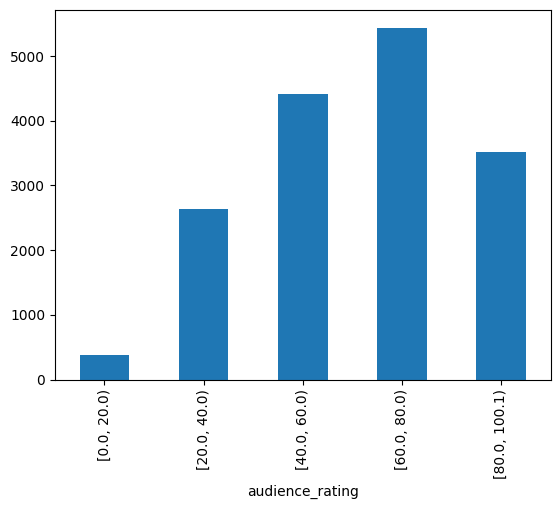

In [ ]:
#tutorial de youtube que he seguido https://www.youtube.com/watch?v=r1ZVISvsaqU
 
#Miro los maximoss
maximos = {
    'runtime_in_minutes': df['runtime_in_minutes'].max(),
    'tomatometer_rating': df['tomatometer_rating'].max(),
    'audience_rating': df['audience_rating'].max(),
    'tomatometer_count': df['tomatometer_count'].max(),
    'audience_count': df['audience_count'].max()
}
display(maximos)
#Miro los minimos
minimos = {
    'runtime_in_minutes': df['runtime_in_minutes'].min(),
    'tomatometer_rating': df['tomatometer_rating'].min(),
    'audience_rating': df['audience_rating'].min(),
    'tomatometer_count': df['tomatometer_count'].min(),
    'audience_count': df['audience_count'].min()
}
display(minimos)
 
#de momento pongo que haya 5 intervalos
intervalos = 5
 
#calcula los intervalos de cada atributo
anchos_intervalos = {
    key: (maximos[key] - minimos[key]) / intervalos
    for key in maximos.keys()
}
anchos_intervalos
 
#Hago la tabla de pfrequencias de audience_rating
tabla_frecuencias = pd.cut(df['audience_rating'],
                          bins=intervalos,
                          right=False).value_counts().sort_index()
display(tabla_frecuencias.to_frame(name='Frecuencia'))
 
tabla_frecuencias.plot(kind='bar')


## 3.1 Estadisticas globales

In [ ]:

#En una arrya pongo las variables numericas de mi datasrt q quiero analizar
numericas = [
    'runtime_in_minutes',
    'tomatometer_rating',
    'audience_rating',
    'tomatometer_count',
    'audience_count',
    'days_to_streaming'
]

#Hago que haga las estadisticas basicas de las variables numericas y que las printee
estadisticos = df[numericas].agg(['mean', 'median', 'std', 'min', 'max'])
print("ESTADÍSTICOS DE VARIABLES NUMÉRICAS:")
print(estadisticos)

#Cantidad peliculas
cantidad_peliculas = len(df)

#Cantidad de estudios 
cantidad_estudios = df['studio_name'].nunique()

#Cantidad de directores 
cantidad_directores = df['directors'].nunique()

# Convertir todos los actores en una lista individual de nombres quitando vacios, seprando por comas y quitando espacios
lista_actores = (
    df['cast']
    .dropna()  
    .str.split(',')  
    .explode() 
    .str.strip() 
)

# Contar actores distintos
actores_unicos = lista_actores.nunique()

#Printeo las cantidades 
print("\nCANTIDADES:")
print("Películas:", cantidad_peliculas)
print("Estudios distintos:", cantidad_estudios)
print("Directores distintos:", cantidad_directores)
print("Actores distintos:", actores_unicos)

ESTADÍSTICOS DE VARIABLES NUMÉRICAS:
        runtime_in_minutes  tomatometer_rating  audience_rating  \
mean            102.392367           60.464146         60.47159   
median           99.000000           66.000000         62.00000   
std              25.028519           28.586446         20.46276   
min               1.000000            0.000000          0.00000   
max            2000.000000          100.000000        100.00000   

        tomatometer_count  audience_count            days_to_streaming  
mean            56.609966    1.524890e+05 3710 days 05:17:28.127721344  
median          28.000000    4.877000e+03            341 days 00:00:00  
std             66.384769    1.817791e+06 6368 days 11:23:45.349425344  
min              5.000000    5.000000e+00         -6364 days +00:00:00  
max            497.000000    3.579764e+07          33506 days 00:00:00  

CANTIDADES:
Películas: 16637
Estudios distintos: 2886
Directores distintos: 8314
Actores distintos: 198667


## 3.2 Análisis por género

In [ ]:

#Creo un datafreme para analizar los generos 
#Primero separo los generos por comas y luego exploto el dataframe para tener una fila por cada genero
df_generos = (
    df.assign(genre=df['genre'].str.split(','))
      .explode('genre')
)

# Quitar espacios en blanco
df_generos['genre'] = df_generos['genre'].str.strip()

#Agrup por genero y analizo por cada generod e peliculas el numero de peliculas q hay, 
#la media de duracion, la media de tomatometer rating y la media de la valoracion de la audiencia
analisis_genero = (
    df_generos.groupby("genre")
        .agg(
            numero_peliculas=("movie_title", "count"),
            duracion_media=("runtime_in_minutes", "mean"),
            rating_criticos_medio=("tomatometer_rating", "mean"),
            rating_audiencia_medio=("audience_rating", "mean")
        )
)

#Para probar como ordenar los resultados he escojido la valoracion por audiencia
# para ordenar los datos ordenop de mayor a menor
analisis_genero_ordenado = analisis_genero.sort_values(
    by="rating_audiencia_medio",
    ascending=False
)
#hago print
print(analisis_genero_ordenado)



                        numero_peliculas  duracion_media  \
genre                                                      
Sports&Fitness                       175       98.725714   
Documentary                         1916       92.543786   
Anime&Manga                           15      100.400000   
SpecialInterest                     1219       93.445813   
Classics                            1578      108.821926   
Musical&PerformingArts               976      102.685185   
Faith&Spirituality                    78      106.051282   
ArtHouse&International              2407      105.564711   
Television                           258      101.445736   
Animation                            565       86.136445   
Western                              283      110.498221   
Nan                                   17       89.647059   
Romance                             1807      108.046771   
Drama                               9005      106.865780   
Gay&Lesbian                           68

## 3.3 Análisis por estudio o director

In [ ]:
#Creo un datafreame para analizar los diferentes estudios del dataset
analisis_estudio = (
    #Los agrupo por studio_name (Lo hago asi directamente pq solo hay un estudio por pelicula)
    df.groupby("studio_name")
      .agg(
          numero_peliculas=("movie_title", "count"), #Aqui cuento cada pelicula usando el campo movie title
          rating_criticos_medio=("tomatometer_rating", "mean"), #Aqui hago la media del tomatometer rating
          rating_audiencia_medio=("audience_rating", "mean"), #Meida de la audiencia
          duracion_media=("runtime_in_minutes", "mean") #Media de duracion
      )
      .sort_values(by="rating_audiencia_medio", ascending=False) #Ordeno por rating de audiencia de mayor a menor
)
#Hago print del analisis
print("ANÁLISIS POR ESTUDIO:")
print(analisis_estudio)



#Ahora hago lo mismo pero para los directores, ceeo un dataframe 
df_directores = (
    #Cojo el campo directores, los separo por comas y hago explode para hacer una fila para cada uno
    df.assign(directors=df['directors'].str.split(','))
      .explode('directors')
)
# Aqui quito espacios en blanco con strip
df_directores['directors'] = df_directores['directors'].str.strip()
analisis_director = (`
#Agrupo por director y analizo los datos`
    df_directores.groupby("directors")
      .agg(
          numero_peliculas=("movie_title", "count"),#Cuento las peliculas que ha hecho ese director
          rating_criticos_medio=("tomatometer_rating", "mean"),#La media de tomatometer que tiene el director basado en sus peliculas
          rating_audiencia_medio=("audience_rating", "mean"),#La media de la audiencoia
          duracion_media=("runtime_in_minutes", "mean")#Media de duracion
      )
      .sort_values(by="rating_audiencia_medio", ascending=False)#Ordeno de mayor a menor
)
#Hago print
print("ANÁLISIS POR DIRECTOR:")
print(analisis_director)

mejor_estudio_audiencia = analisis_estudio.nlargest(1, "rating_audiencia_medio")
print("Mejor estudio según audiencia:")
print(mejor_estudio_audiencia)
mejor_estudio_criticos = analisis_estudio.nlargest(1, "rating_criticos_medio")
print("Mejor estudio según críticos:")
print(mejor_estudio_criticos)
mejor_director_audiencia = analisis_director.nlargest(1, "rating_audiencia_medio")
print("Mejor director según audiencia:")
print(mejor_director_audiencia)
mejor_director_criticos = analisis_director.nlargest(1, "rating_criticos_medio")
print("Mejor director según críticos:")
print(mejor_director_criticos)



ANÁLISIS POR ESTUDIO:
                                 numero_peliculas  rating_criticos_medio  \
studio_name                                                                
Milestone Films                                 1                   89.0   
NEON/Hulu                                       1                   83.0   
HBO Sports                                      1                  100.0   
Big Mouth Productions                           1                  100.0   
Shadowbox Films                                 1                   88.0   
...                                           ...                    ...   
Warner Bros. Home Entertainment                 1                   44.0   
Warner Brothers Classics                        1                   90.0   
Well Go USA Inc.                                1                   71.0   
WigglyWorld Studios                             1                   40.0   
Zentropa Entertainments                         1                 

## 3.4 Analisis temporal

ANÁLISIS TEMPORAL:
        numero_peliculas  rating_audiencia_medio
year                                            
1914.0                 1               69.000000
1915.0                 2               56.000000
1916.0                 1               77.000000
1919.0                 1               52.000000
1920.0                 4               75.750000
...                  ...                     ...
2015.0               238               54.067797
2016.0               260               53.439689
2017.0               234               56.819383
2018.0               236               57.995614
2019.0               168               62.579618

[103 rows x 2 columns]


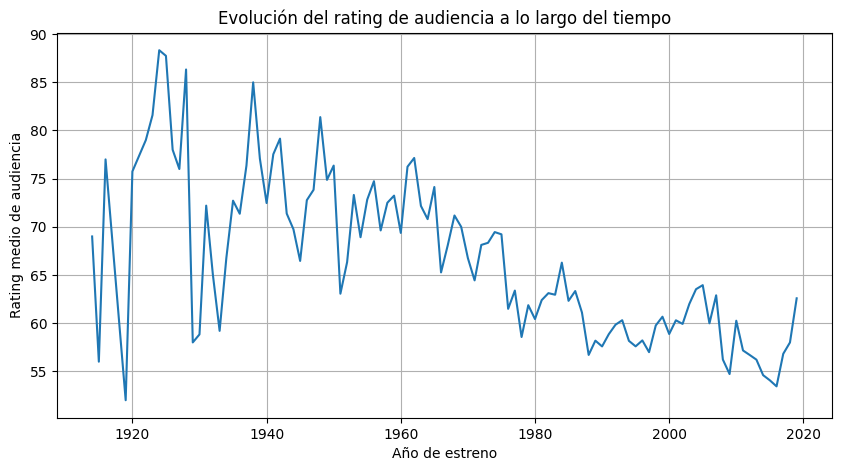

In [ ]:



# Del campo in_theaters_date extrago el año
df['year'] = df['in_theaters_date'].dt.year
analisis_temporal = (
    df.groupby("year")
      .agg(
          numero_peliculas=("movie_title", "count"), #Cuento el numero de peliculas que hay en ese año
          rating_audiencia_medio=("audience_rating", "mean") #Y tambien hago la media del rating de la uadiencia
      )
      .sort_index()  #Ordeno por año para q sea mas vistoso
)

#Hago print de los datos tal cual
print("ANÁLISIS TEMPORAL:")
print(analisis_temporal)

#Ahora hago una grafica para que se muestre mejor
plt.figure(figsize=(10,5))#Le doy una medida
plt.plot(analisis_temporal.index, analisis_temporal["rating_audiencia_medio"])#Le indicolos ejes q quiero
plt.xlabel("Año de estreno")#Le assigno el titlo al eje x
plt.ylabel("Rating medio de audiencia") # y al eje y
plt.title("Evolución del rating de audiencia a lo largo del tiempo")#El titulo de la grafica
plt.grid(True)#Activo q se vea la cuadricula pq creo que queda mejor
plt.show()#Hago print


## 3.5 Análisis de retraso a streaming (si aplica)

===== ESTADÍSTICOS DE days_to_streaming_num (en días) =====
count     6890.000000
mean      3710.220464
std       6368.474830
min      -6364.000000
25%        109.000000
50%        341.000000
75%       4873.250000
max      33506.000000
Name: days_to_streaming_num, dtype: float64 



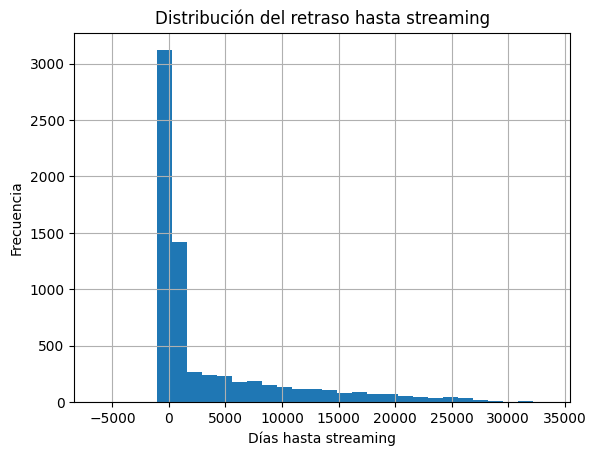

Correlación entre days_to_streaming_num y audience_rating: 0.21685520594960866
Correlación entre days_to_streaming_num y tomatometer_rating: 0.28776170166921156 



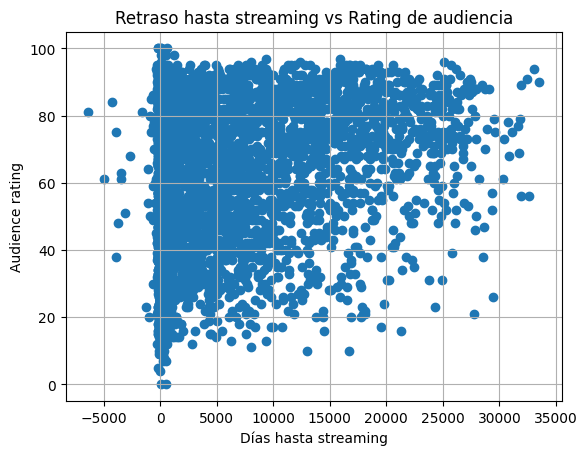

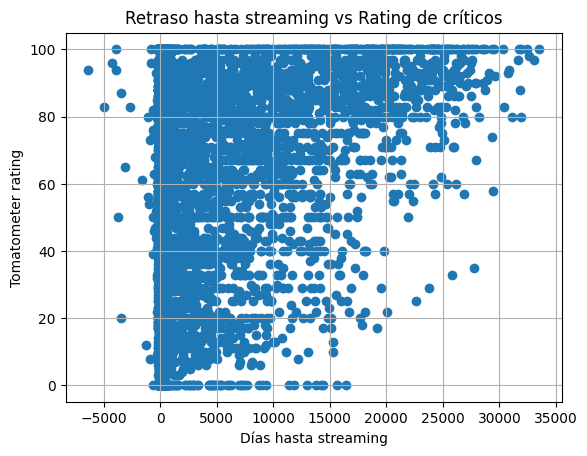

In [19]:

# 3.5 Relación entre días hasta streaming y ratings

import numpy as np
import matplotlib.pyplot as plt

# 1) Pasar de timedelta a número de días (o copiar si ya es numérica)
if np.issubdtype(df["days_to_streaming"].dtype, np.timedelta64):
    df["days_to_streaming_num"] = df["days_to_streaming"] / np.timedelta64(1, "D")
    # Alternativa equivalente:
    # df["days_to_streaming_num"] = df["days_to_streaming"].dt.days
else:
    # Si ya es numérica, simplemente la copiamos
    df["days_to_streaming_num"] = df["days_to_streaming"]

# 2) Estadísticos descriptivos del retraso hasta streaming
print("===== ESTADÍSTICOS DE days_to_streaming_num (en días) =====")
print(df["days_to_streaming_num"].describe(), "\n")

# 3) Histograma de la distribución del retraso
plt.figure()
plt.hist(df["days_to_streaming_num"].dropna(), bins=30)
plt.xlabel("Días hasta streaming")
plt.ylabel("Frecuencia")
plt.title("Distribución del retraso hasta streaming")
plt.grid(True)
plt.show()

# 4) Correlación entre retraso y ratings

# ---- Con audience_rating ----
mask_aud = df["days_to_streaming_num"].notna() & df["audience_rating"].notna()

corr_audience = np.corrcoef(
    df.loc[mask_aud, "days_to_streaming_num"],
    df.loc[mask_aud, "audience_rating"]
)[0, 1]

print("Correlación entre days_to_streaming_num y audience_rating:", corr_audience)

# ---- Con tomatometer_rating ----
mask_crit = df["days_to_streaming_num"].notna() & df["tomatometer_rating"].notna()

corr_critics = np.corrcoef(
    df.loc[mask_crit, "days_to_streaming_num"],
    df.loc[mask_crit, "tomatometer_rating"]
)[0, 1]

print("Correlación entre days_to_streaming_num y tomatometer_rating:", corr_critics, "\n")

# 5) Gráficos de dispersión

# Retraso vs rating de audiencia
plt.figure()
plt.scatter(
    df.loc[mask_aud, "days_to_streaming_num"],
    df.loc[mask_aud, "audience_rating"]
)
plt.xlabel("Días hasta streaming")
plt.ylabel("Audience rating")
plt.title("Retraso hasta streaming vs Rating de audiencia")
plt.grid(True)
plt.show()

# Retraso vs rating de críticos
plt.figure()
plt.scatter(
    df.loc[mask_crit, "days_to_streaming_num"],
    df.loc[mask_crit, "tomatometer_rating"]
)
plt.xlabel("Días hasta streaming")
plt.ylabel("Tomatometer rating")
plt.title("Retraso hasta streaming vs Rating de críticos")
plt.grid(True)
plt.show()



## 4. Uso de NumPy para análisis auxiliar

Percentiles de duración (runtime_in_minutes):
  P90: 125.00 minutos
  P95: 135.95 minutos

Películas muy largas (>= P95 de duración):


,movie_title,runtime_in_minutes,tomatometer_rating,audience_rating
13,The Lost City,143.0,25,64.0
36,A Farewell To Arms,152.0,0,36.0
44,The Alamo,161.0,50,63.0
51,Aliens,138.0,99,94.0
53,All About Eve,138.0,100,94.0
59,All Quiet on the Western Front,150.0,100,70.0
115,Laaga Chunari Mein Daag - Journey of a Woman,138.0,50,58.0
121,Saawariya,138.0,38,46.0
122,Aaja Nachle,142.0,67,72.0
130,Badland,165.0,17,54.0



Percentiles de rating:
  P10 audience_rating: 32.00
  P10 tomatometer_rating: 17.00

Películas con audience_rating muy bajo (<= P10):


,movie_title,audience_rating,tomatometer_rating
31,Ultraviolet,30.0,8
52,Rise: Blood Hunter,20.0,36
69,The 4th Dimension,31.0,63
74,Gone,20.0,54
78,The Tiger's Tail,31.0,14
80,Slipstream,29.0,25
85,The Happening,24.0,18
100,Day of the Dead,22.0,13
107,Whiteout,21.0,7
118,House,27.0,0


Películas con tomatometer_rating muy bajo (<= P10):


...


===== Diferencia audience_rating - tomatometer_rating =====
Media de la diferencia: 0.15
Desviación típica de la diferencia: 21.53

Películas donde la audiencia valora MUCHO más alto que la crítica (>= media + 1*std):


,movie_title,audience_rating,tomatometer_rating,aud_minus_tom
1991,96 Souls,95.0,0,95.0
8014,Is That a Gun in Your Pocket?,92.0,0,92.0
7136,Hating Breitbart,92.0,0,92.0
13666,The After Party,89.0,0,89.0
1739,Home,86.0,0,86.0
1140,Fall,84.0,0,84.0
722,Sparkle,91.0,10,81.0
2160,A Violent Separation,90.0,10,80.0
10269,Mysteries Of The Jesus Prayer,100.0,20,80.0
2434,All Relative,90.0,10,80.0



Películas donde la crítica valora más alto que la audiencia (<= media - 1*std):


,movie_title,audience_rating,tomatometer_rating,aud_minus_tom
10875,Outside the Law,0.0,86,-86.0
5809,Everybody Knows... Elizabeth Murray,17.0,100,-83.0
8565,Knock Down the House,17.0,100,-83.0
15833,Vengeance Valley,20.0,100,-80.0
7045,Hannah Gadsby: Nanette,22.0,100,-78.0
15434,Traffic Stop,23.0,100,-77.0
4839,Daisy Miller,24.0,100,-76.0
2599,Amy Schumer Growing,4.0,79,-75.0
1518,Angel Rodriguez,11.0,83,-72.0
7036,Hangman,29.0,100,-71.0



===== Distribución de runtime_in_minutes (con np.histogram) =====
[   1.0,  200.9) -> 16441 películas
[ 200.9,  400.8) -> 38 películas
[ 400.8,  600.7) -> 2 películas
[ 600.7,  800.6) -> 0 películas
[ 800.6, 1000.5) -> 0 películas
[1000.5, 1200.4) -> 0 películas
[1200.4, 1400.3) -> 0 películas
[1400.3, 1600.2) -> 0 películas
[1600.2, 1800.1) -> 0 películas
[1800.1, 2000.0) -> 1 películas


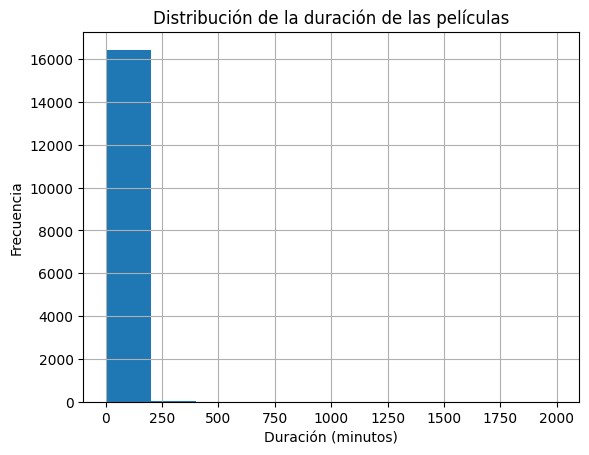


===== Distribución de audience_rating (con np.histogram) =====
[   0,   10) -> 34 películas
[  10,   20) -> 343 películas
[  20,   30) -> 957 películas
[  30,   40) -> 1680 películas
[  40,   50) -> 2122 películas
[  50,   60) -> 2296 películas
[  60,   70) -> 2558 películas
[  70,   80) -> 2883 películas
[  80,   90) -> 2630 películas
[  90,  100) -> 882 películas


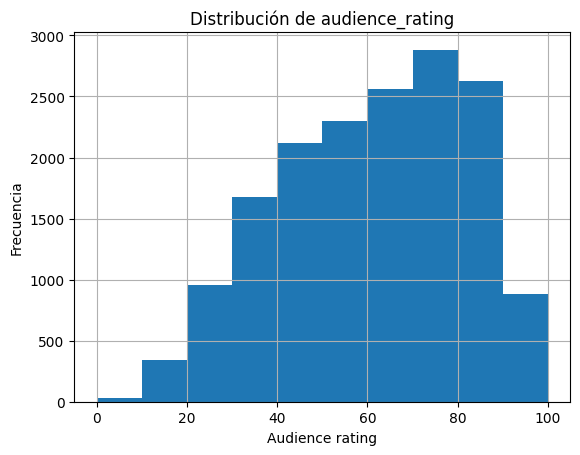

In [21]:
# 5. Uso de NumPy para análisis auxiliar

import numpy as np
import matplotlib.pyplot as plt

# =============================
# 5.1 Percentiles y películas "fuera de lo común"
# =============================

runtime = df["runtime_in_minutes"].to_numpy()
aud = df["audience_rating"].to_numpy()
tom = df["tomatometer_rating"].to_numpy()

# Percentiles de duración (películas muy largas)
p90_runtime = np.nanpercentile(runtime, 90)
p95_runtime = np.nanpercentile(runtime, 95)

print("Percentiles de duración (runtime_in_minutes):")
print(f"  P90: {p90_runtime:.2f} minutos")
print(f"  P95: {p95_runtime:.2f} minutos\n")

# Películas muy largas (>= P95)
pelis_muy_largas = df[df["runtime_in_minutes"] >= p95_runtime][
    ["movie_title", "runtime_in_minutes", "tomatometer_rating", "audience_rating"]
]
print("Películas muy largas (>= P95 de duración):")
display(pelis_muy_largas.head(10))

# Percentiles bajos para ratings (películas con rating muy bajo)
p10_aud = np.nanpercentile(aud, 10)
p10_tom = np.nanpercentile(tom, 10)

print("\nPercentiles de rating:")
print(f"  P10 audience_rating: {p10_aud:.2f}")
print(f"  P10 tomatometer_rating: {p10_tom:.2f}\n")

# Películas con audiencia muy baja
pelis_aud_baja = df[df["audience_rating"] <= p10_aud][
    ["movie_title", "audience_rating", "tomatometer_rating"]
]
print("Películas con audience_rating muy bajo (<= P10):")
display(pelis_aud_baja.head(10))

# Películas con crítica muy baja
pelis_tom_bajo = df[df["tomatometer_rating"] <= p10_tom][
    ["movie_title", "tomatometer_rating", "audience_rating"]
]
print("Películas con tomatometer_rating muy bajo (<= P10):")
display(pelis_tom_bajo.head(10))


# =============================
# 5.2 Diferencia audience_rating - tomatometer_rating
# =============================

diff_aud_tom = aud - tom            # operación vectorizada
df["aud_minus_tom"] = diff_aud_tom  # guardamos en el DataFrame

media_diff = np.nanmean(diff_aud_tom)
std_diff = np.nanstd(diff_aud_tom)

print("\n===== Diferencia audience_rating - tomatometer_rating =====")
print(f"Media de la diferencia: {media_diff:.2f}")
print(f"Desviación típica de la diferencia: {std_diff:.2f}\n")

# Películas donde la audiencia valora mucho más que la crítica
umbral_alta_dif = media_diff + std_diff
pelis_aud_mucho_mas_alta = df[df["aud_minus_tom"] >= umbral_alta_dif][
    ["movie_title", "audience_rating", "tomatometer_rating", "aud_minus_tom"]
].sort_values("aud_minus_tom", ascending=False)

print("Películas donde la audiencia valora MUCHO más alto que la crítica (>= media + 1*std):")
display(pelis_aud_mucho_mas_alta.head(10))

# Opcional: películas donde la crítica es más alta que la audiencia
umbral_crit_mas_alta = media_diff - std_diff
pelis_critica_mas_alta = df[df["aud_minus_tom"] <= umbral_crit_mas_alta][
    ["movie_title", "audience_rating", "tomatometer_rating", "aud_minus_tom"]
].sort_values("aud_minus_tom")

print("\nPelículas donde la crítica valora más alto que la audiencia (<= media - 1*std):")
display(pelis_critica_mas_alta.head(10))


# =============================
# 5.3 Histogramas / distribuciones con NumPy
# =============================

# --- Distribución de la duración ---
runtime_sin_nan = runtime[~np.isnan(runtime)]
counts_rt, bins_rt = np.histogram(runtime_sin_nan, bins=10)

print("\n===== Distribución de runtime_in_minutes (con np.histogram) =====")
for i in range(len(counts_rt)):
    print(f"[{bins_rt[i]:6.1f}, {bins_rt[i+1]:6.1f}) -> {counts_rt[i]} películas")

plt.figure()
plt.hist(runtime_sin_nan, bins=10)
plt.xlabel("Duración (minutos)")
plt.ylabel("Frecuencia")
plt.title("Distribución de la duración de las películas")
plt.grid(True)
plt.show()

# --- Distribución de audience_rating ---
aud_sin_nan = aud[~np.isnan(aud)]
counts_aud, bins_aud = np.histogram(aud_sin_nan, bins=np.arange(0, 101, 10))

print("\n===== Distribución de audience_rating (con np.histogram) =====")
for i in range(len(counts_aud)):
    print(f"[{bins_aud[i]:4.0f}, {bins_aud[i+1]:4.0f}) -> {counts_aud[i]} películas")

plt.figure()
plt.hist(aud_sin_nan, bins=np.arange(0, 101, 10))
plt.xlabel("Audience rating")
plt.ylabel("Frecuencia")
plt.title("Distribución de audience_rating")
plt.grid(True)
plt.show()



## 5. Preguntes

¿Qué género tiene el rating medio de audiencia más alto y cuál el más bajo?

¿Hay diferencias significativas entre el rating de los críticos (tomatometer_rating) y el de la audiencia (audience_rating)? Por ejemplo, ¿qué películas tienen una gran disparidad entre ambos?

¿Cuál estudio produce las películas con duración media más alta? ¿Y cuál las que tienen mejor rating de audiencia medio?

¿Ha cambiado la duración promedio de las películas a lo largo de los años? ¿Ha cambiado también el rating medio de audiencia?

¿Existe alguna relación entre el retraso hasta streaming (days_to_streaming) y el rating de audiencia? ¿Las películas que llegan más rápido al streaming obtienen mejores valoraciones?


## 6. Conclusiones